In [2]:
%pip install pandas matplotlib numpy seaborn scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [14]:
df = pd.read_csv("../data/data.csv")
df.head()

,Unnamed: 0,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,1,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,...,71,93,79,181,180,91,5,4,2,2
1,2,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,...,86,98,78,201,182,92,5,4,4,4
2,3,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,...,18,43,22,113,113,7,1,1,1,1
3,4,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,...,76,80,48,137,157,67,4,3,2,2
4,5,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,...,98,100,71,189,198,98,5,4,4,2


In [7]:
df.describe()

,Unnamed: 0,...10,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
count,12411.00000,0.0,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.00000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000
mean,6206.00000,NaN,64.320764,60.778422,60.705181,63.950528,61.801064,77.417291,62.199339,59.18677,67.498348,53.703408,145.476593,162.710499,68.446459,3.885747,3.188865,2.598904,2.409395
std,3582.89143,NaN,11.873650,10.025876,10.120524,11.156869,14.297777,22.673444,27.666558,28.99184,25.495096,30.001734,40.126386,23.112479,25.867550,1.248431,0.979043,1.111704,0.926765
min,1.00000,NaN,26.000000,24.000000,0.000000,11.000000,26.000000,1.000000,1.000000,1.00000,1.000000,0.000000,1.000000,37.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3103.50000,NaN,56.000000,54.000000,54.000000,56.000000,50.000000,65.000000,42.000000,36.00000,51.000000,28.000000,124.000000,147.000000,51.000000,3.000000,3.000000,2.000000,2.000000
50%,6206.00000,NaN,64.000000,61.000000,60.000000,64.000000,59.000000,85.000000,67.000000,65.00000,74.000000,56.000000,153.000000,163.000000,75.000000,4.000000,4.000000,2.000000,2.000000
75%,9308.50000,NaN,72.000000,67.000000,67.000000,71.000000,72.000000,96.000000,86.000000,85.00000,88.000000,80.000000,174.000000,179.000000,90.000000,5.000000,4.000000,4.000000,3.000000
max,12411.00000,NaN,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,300.000000,247.000000,100.000000,5.000000,4.000000,4.000000,4.000000


In [15]:
df["AVG_S11"] = df.apply(lambda x: np.sum(x[["MAT_S11", "CR_S11", "CC_S11", "BIO_S11", "ENG_S11"]])/5, axis=1)
df["AVG_S11"].head()

0    76.2
1    82.4
2    45.4
3    59.8
4    79.6
Name: AVG_S11, dtype: float64

In [10]:
df.columns

Index(['Unnamed: 0', 'COD_S11', 'GENDER', 'EDU_FATHER', 'EDU_MOTHER',
       'OCC_FATHER', 'OCC_MOTHER', 'STRATUM', 'SISBEN', 'PEOPLE_HOUSE',
       '...10', 'INTERNET', 'TV', 'COMPUTER', 'WASHING_MCH', 'MIC_OVEN', 'CAR',
       'DVD', 'FRESH', 'PHONE', 'MOBILE', 'REVENUE', 'JOB', 'SCHOOL_NAME',
       'SCHOOL_NAT', 'SCHOOL_TYPE', 'MAT_S11', 'CR_S11', 'CC_S11', 'BIO_S11',
       'ENG_S11', 'Cod_SPro', 'UNIVERSITY', 'ACADEMIC_PROGRAM', 'QR_PRO',
       'CR_PRO', 'CC_PRO', 'ENG_PRO', 'WC_PRO', 'FEP_PRO', 'G_SC',
       'PERCENTILE', '2ND_DECILE', 'QUARTILE', 'SEL', 'SEL_IHE', 'AVG_S11'],
      dtype='object')

## EDA

In [16]:
cool_vars = ["AVG_S11", "GENDER", "EDU_FATHER", "EDU_MOTHER", "OCC_FATHER", "OCC_MOTHER", "STRATUM", "SISBEN",
            "PEOPLE_HOUSE", "INTERNET", "COMPUTER", "PHONE", "REVENUE", "JOB", "SCHOOL_NAME", "SCHOOL_NAT",
            "SCHOOL_TYPE", "UNIVERSITY", "ACADEMIC_PROGRAM", "SEL", "SEL_IHE", "G_SC"]
df1 = df[cool_vars]

In [17]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12411 entries, 0 to 12410
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   AVG_S11           12411 non-null  float64
 1   GENDER            12411 non-null  object 
 2   EDU_FATHER        12411 non-null  object 
 3   EDU_MOTHER        12411 non-null  object 
 4   OCC_FATHER        12411 non-null  object 
 5   OCC_MOTHER        12411 non-null  object 
 6   STRATUM           12411 non-null  object 
 7   SISBEN            12411 non-null  object 
 8   PEOPLE_HOUSE      12411 non-null  object 
 9   INTERNET          12411 non-null  object 
 10  COMPUTER          12411 non-null  object 
 11  PHONE             12411 non-null  object 
 12  REVENUE           12411 non-null  object 
 13  JOB               12411 non-null  object 
 14  SCHOOL_NAME       12411 non-null  object 
 15  SCHOOL_NAT        12411 non-null  object 
 16  SCHOOL_TYPE       12411 non-null  object

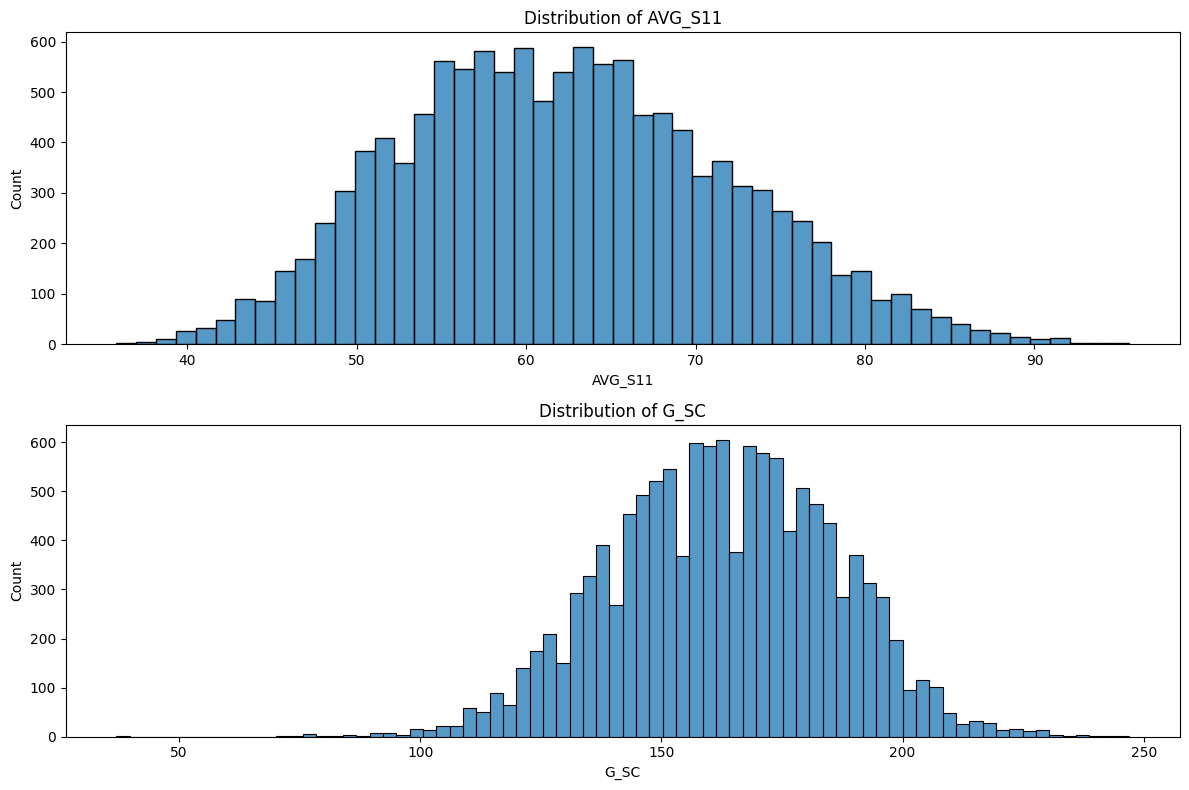

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes = axes.flatten()

sns.histplot(df1["AVG_S11"], ax=axes[0])
sns.histplot(df1["G_SC"], ax=axes[1])

axes[0].set_title("Distribution of AVG_S11")
axes[1].set_title("Distribution of G_SC")

plt.tight_layout()
plt.show()

In [19]:
categorical_vars = ["GENDER", "EDU_FATHER", "EDU_MOTHER", "OCC_FATHER", "OCC_MOTHER", "STRATUM", "SISBEN",
            "PEOPLE_HOUSE", "INTERNET", "COMPUTER", "PHONE", "REVENUE", "JOB", "SCHOOL_NAME", "SCHOOL_NAT",
            "SCHOOL_TYPE", "UNIVERSITY", "ACADEMIC_PROGRAM", "SEL", "SEL_IHE"]

/var/folders/8h/rxm2128d7qn4l7kqdy6pv8wc0000gn/T/ipykernel_81699/3888069132.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/var/folders/8h/rxm2128d7qn4l7kqdy6pv8wc0000gn/T/ipykernel_81699/3888069132.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/var/folders/8h/rxm2128d7qn4l7kqdy6pv8wc0000gn/T/ipykernel_81699/3888069132.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/var/folders/8h/rxm2128d7qn4l7kqdy6pv8wc0000gn/T/ipykernel_81699/3888069132.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after

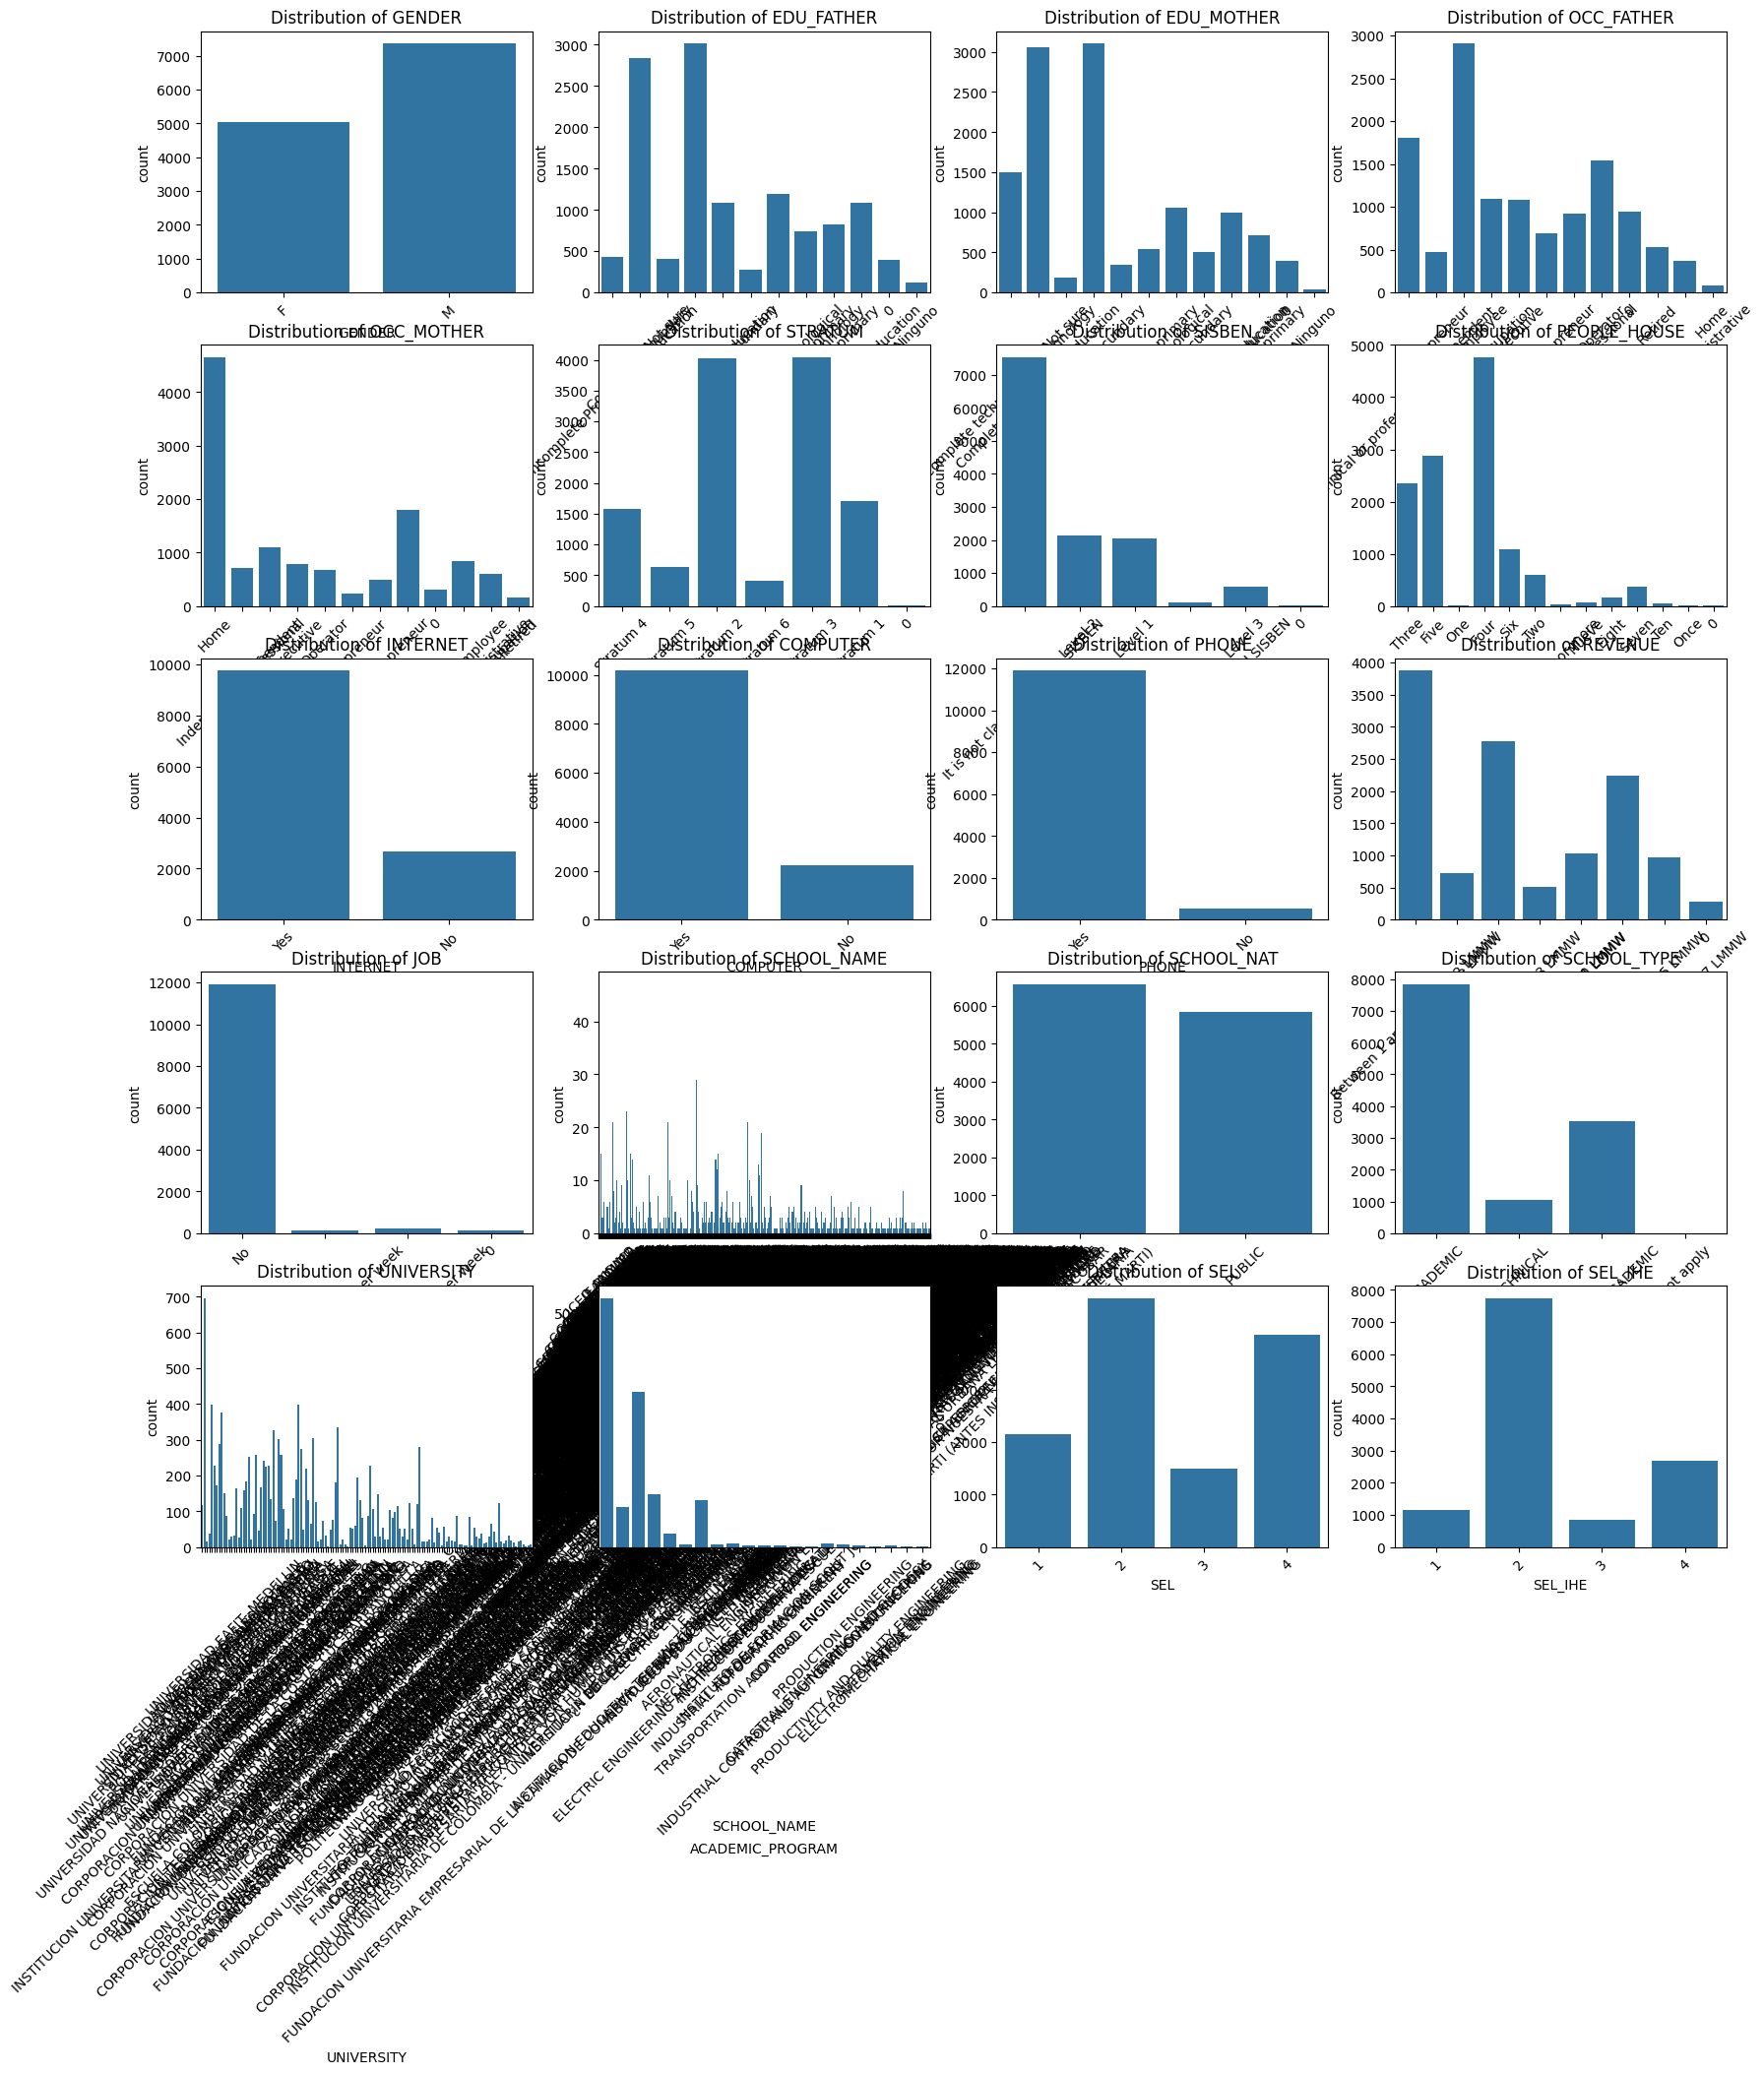

In [ ]:
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    sns.countplot(x=var, data=df1, ax=axes[i])
    plt.sca(axes[i])
    plt.title(f"Distribution of {var}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Mein gott was ist das

In [32]:
categorical_vars = ["GENDER", "EDU_FATHER", "EDU_MOTHER", "OCC_FATHER", "OCC_MOTHER", "STRATUM", "SISBEN",
            "PEOPLE_HOUSE", "INTERNET", "COMPUTER", "PHONE", "REVENUE", "JOB", "SCHOOL_NAT",
            "SCHOOL_TYPE", "ACADEMIC_PROGRAM", "SEL", "SEL_IHE"]

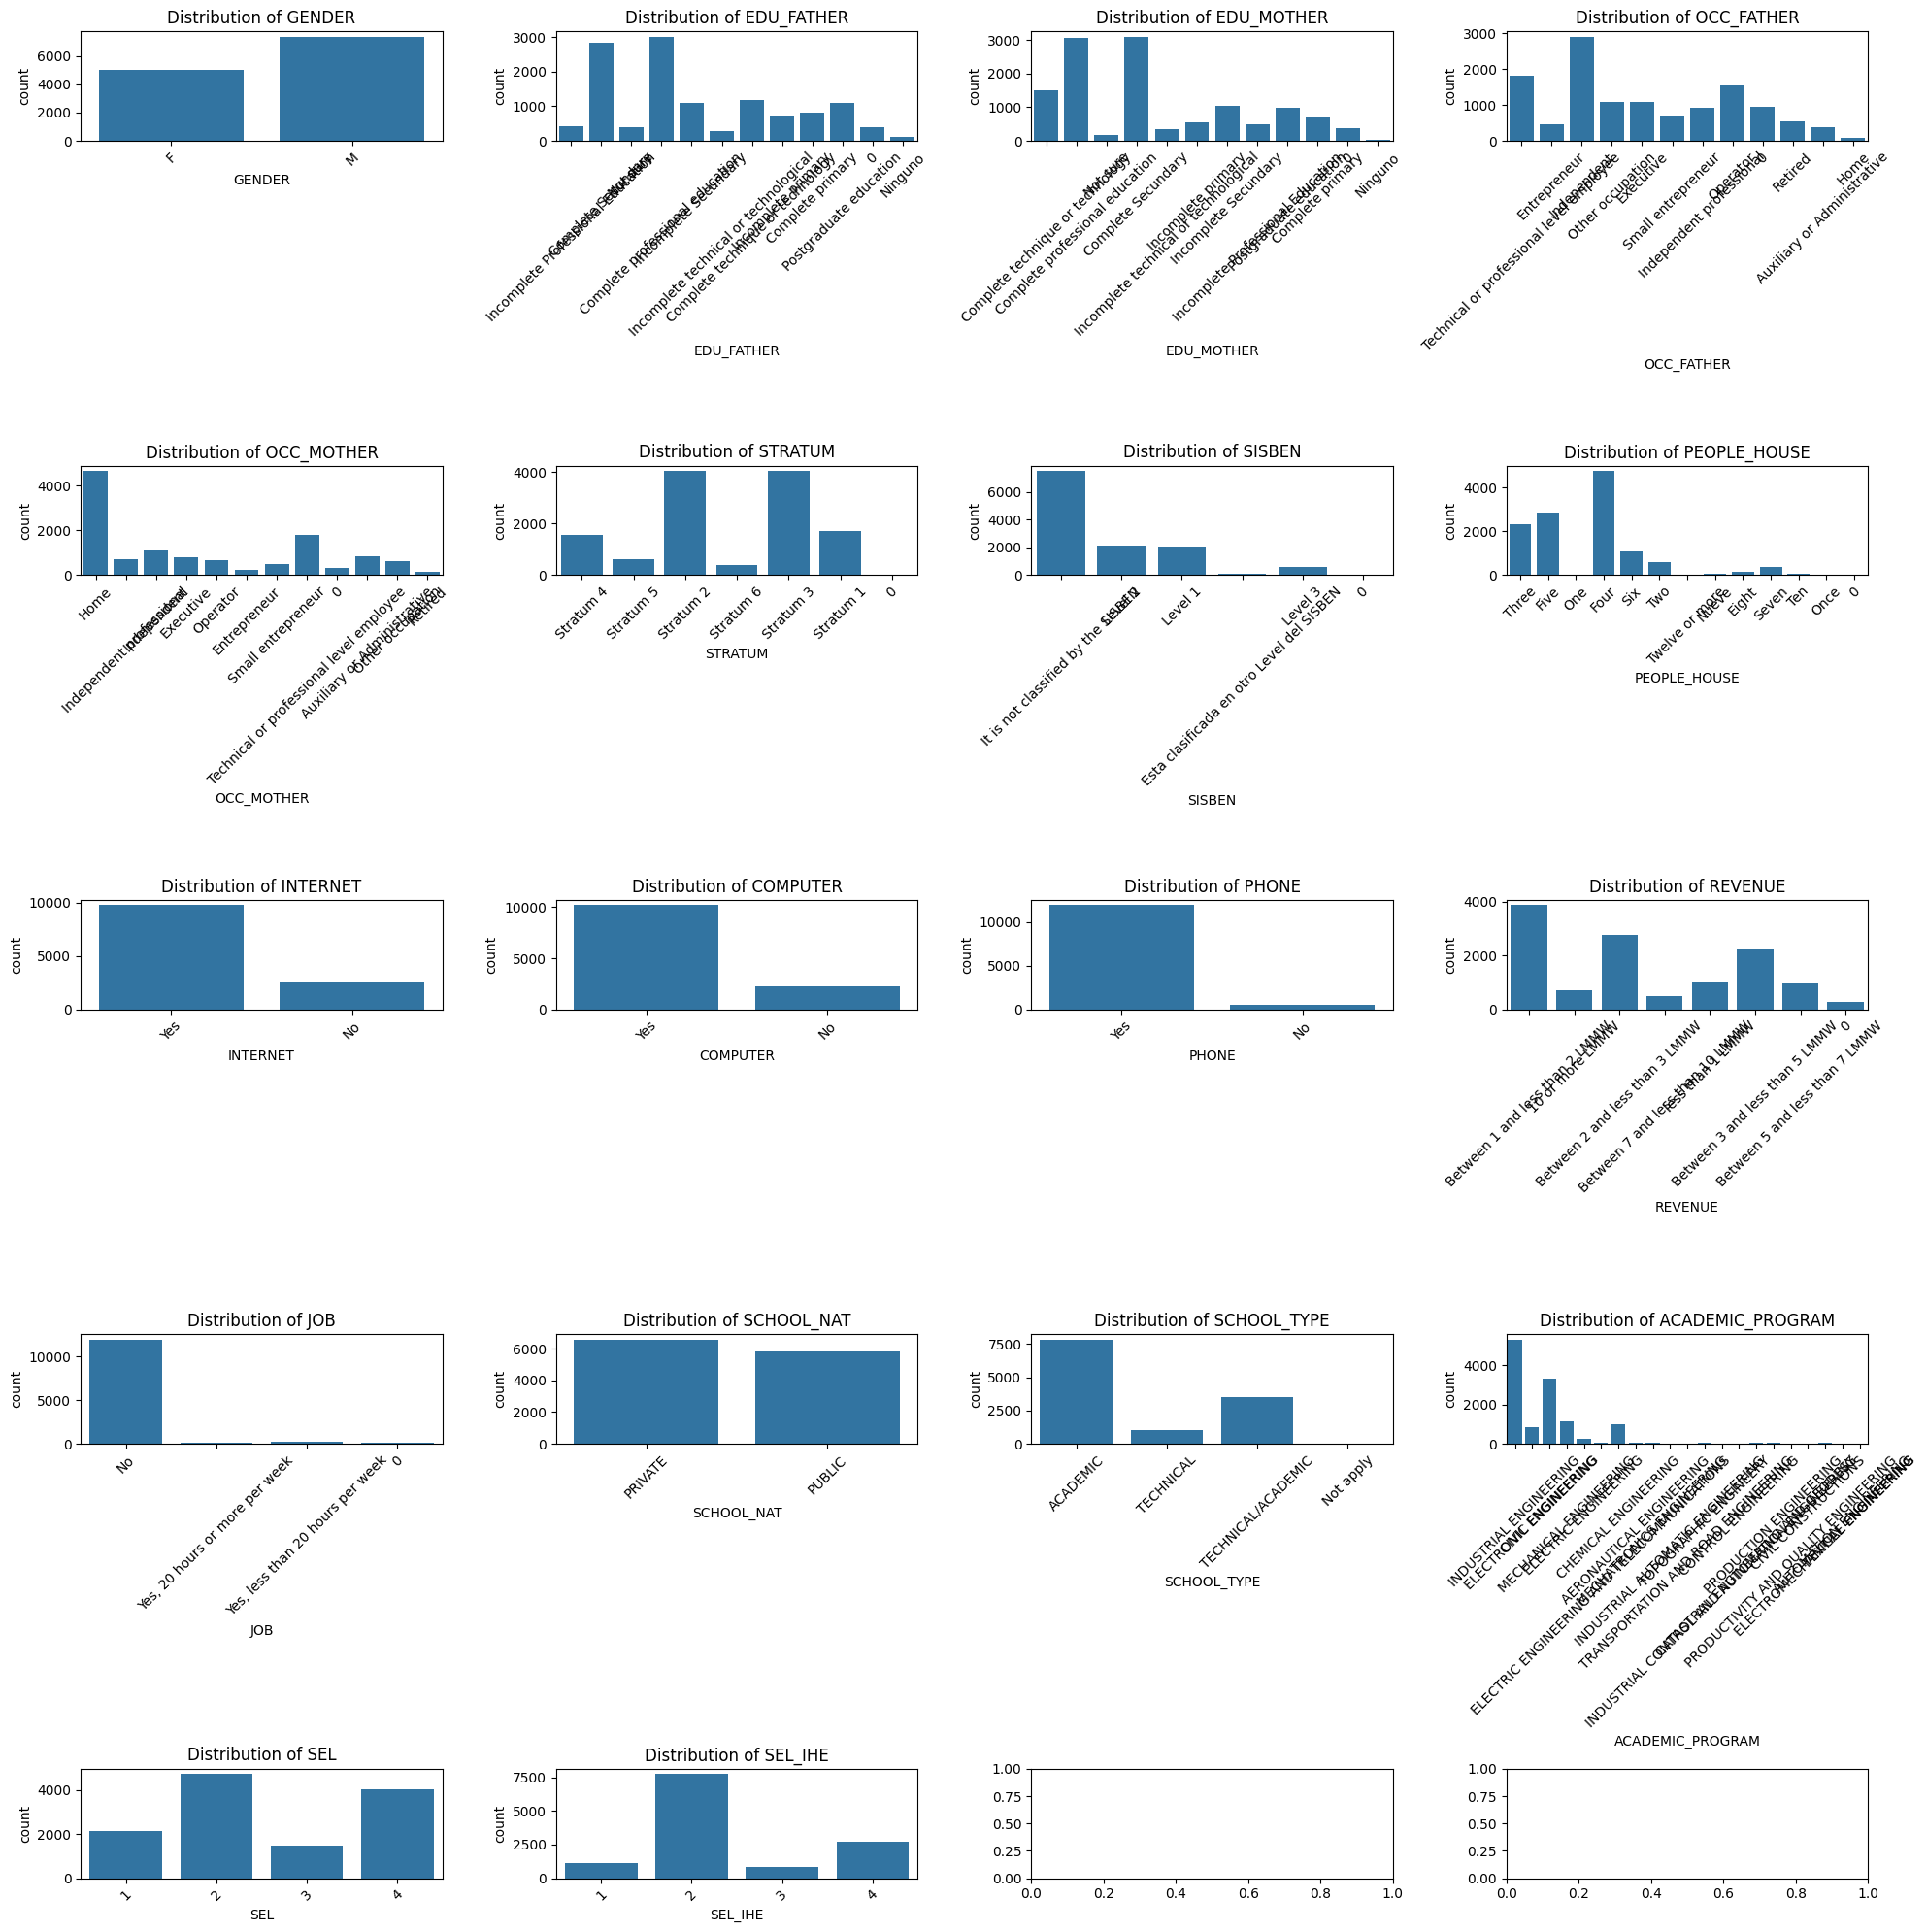

In [33]:
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    sns.countplot(x=var, data=df1, ax=axes[i])
    plt.sca(axes[i])
    plt.title(f"Distribution of {var}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Things to Cull off
* Job has a very ugly distribution, not epic
* Academic Program also very ugly, not epic
<!-- * Occupation of father and mother probably not too important for predicting this stuff so also cull? -->

In [37]:
new_vars = ["GENDER", "EDU_FATHER", "EDU_MOTHER", "OCC_FATHER", "OCC_MOTHER", "STRATUM", "SISBEN",
            "PEOPLE_HOUSE", "INTERNET", "COMPUTER", "PHONE", "REVENUE", "SCHOOL_NAT",
            "SCHOOL_TYPE", "SEL", "SEL_IHE", "AVG_S11", "G_SC"]
features = ["GENDER", "EDU_FATHER", "EDU_MOTHER", "OCC_FATHER", "OCC_MOTHER", "STRATUM", "SISBEN",
            "PEOPLE_HOUSE", "INTERNET", "COMPUTER", "PHONE", "REVENUE", "SCHOOL_NAT",
            "SCHOOL_TYPE", "SEL", "SEL_IHE", "AVG_S11"]

In [38]:
from sklearn.preprocessing import LabelEncoder

# Create a new dataframe to store encoded values
df1_encoded = df1.copy()

# Encode each categorical variable
for column in categorical_vars:
    if column in df1.columns:  # Check if column exists in df1
        le = LabelEncoder()
        df1_encoded[column] = le.fit_transform(df1[column])

# Keep the numeric columns as they are
df1_encoded[['AVG_S11', 'G_SC']] = df1[['AVG_S11', 'G_SC']]

In [39]:
df1_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12411 entries, 0 to 12410
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   AVG_S11           12411 non-null  float64
 1   GENDER            12411 non-null  int64  
 2   EDU_FATHER        12411 non-null  int64  
 3   EDU_MOTHER        12411 non-null  int64  
 4   OCC_FATHER        12411 non-null  int64  
 5   OCC_MOTHER        12411 non-null  int64  
 6   STRATUM           12411 non-null  int64  
 7   SISBEN            12411 non-null  int64  
 8   PEOPLE_HOUSE      12411 non-null  int64  
 9   INTERNET          12411 non-null  int64  
 10  COMPUTER          12411 non-null  int64  
 11  PHONE             12411 non-null  int64  
 12  REVENUE           12411 non-null  int64  
 13  JOB               12411 non-null  int64  
 14  SCHOOL_NAME       12411 non-null  object 
 15  SCHOOL_NAT        12411 non-null  int64  
 16  SCHOOL_TYPE       12411 non-null  int64 

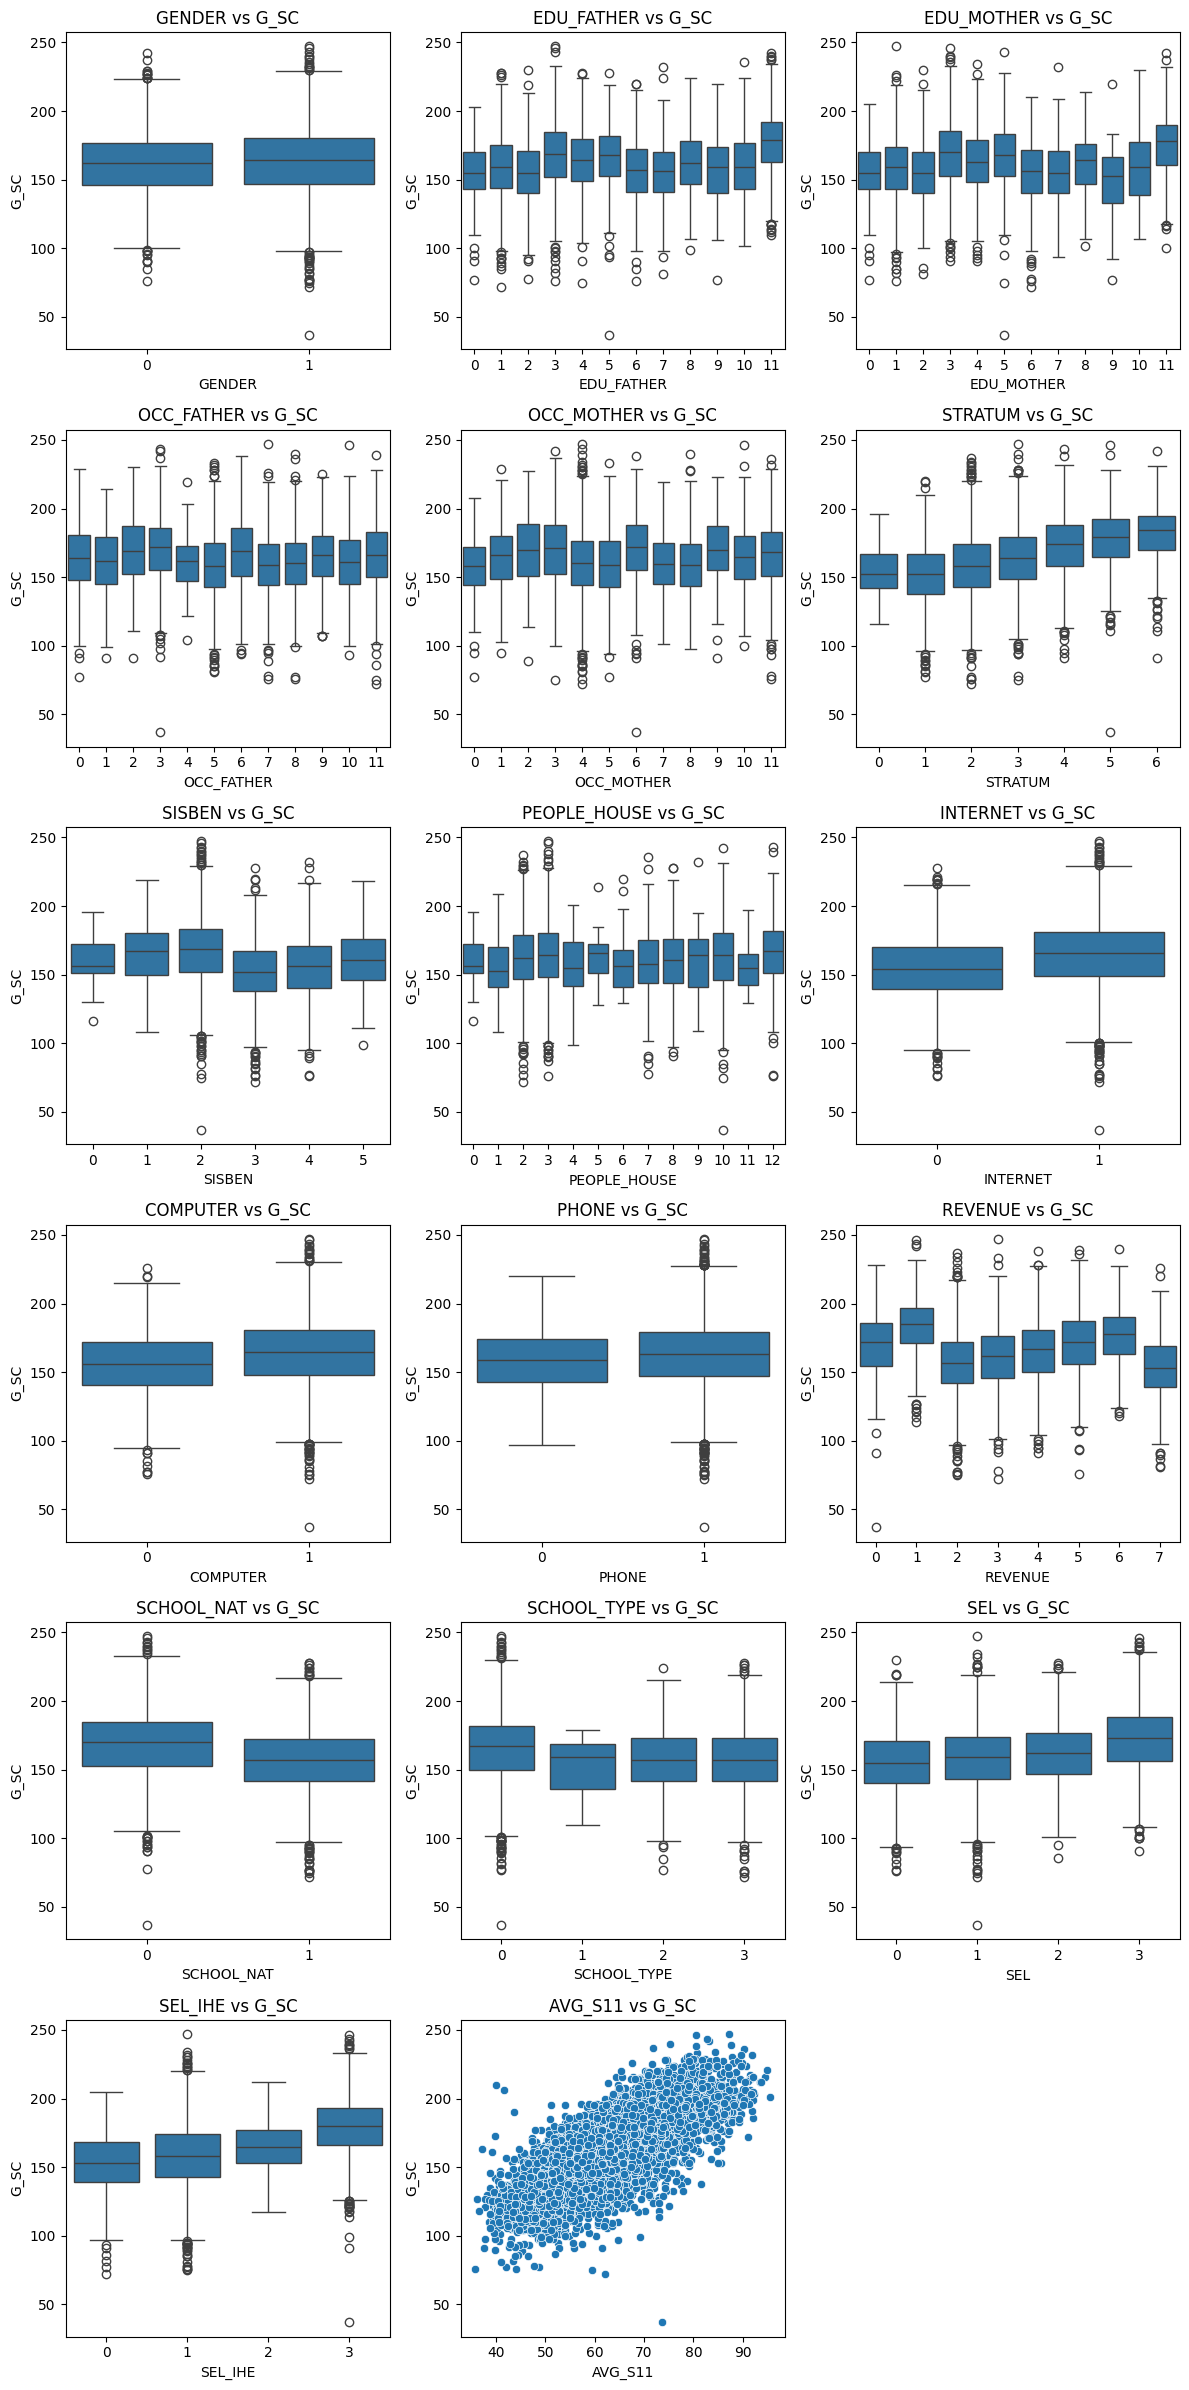

In [ ]:
# Relations with G_SC
# Care that the categorical stuff are encoded as ints but aren't actually ordinal
fig, axes = plt.subplots(6, 3, figsize=(12, 24))
axes = axes.flatten()

for i, feature in enumerate(features):
    if df1_encoded[feature].dtype == int:
        sns.boxplot(x=feature, y="G_SC", data=df1_encoded, ax=axes[i])
    else:
        sns.scatterplot(x=feature, y="G_SC", data=df1_encoded, ax=axes[i])
    axes[i].set_title(f"{feature} vs G_SC")

axes[17].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# interactions with